In [2]:
import geopandas as gpd
import pandas as pd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np
from utils import *
import osmnx as ox
import os
    

In [3]:
%matplotlib widget
#%matplotlib inline

In [5]:
list_districts = ["Barcelona", "Ciutat Vella", "Eixample", "Sants–Montjuic", "Les Corts", "Sarria-Sant Gervasi", "Gracia", "Horta-Guinardo", "Nou Barris", "Sant Andreu", "Sant Marti"]
graph_dict={}
for district in list_districts:
    filepath = district+".graphml"
    if not os.path.isfile(district+".graphml"):
        print("Downloading ",district,"from Internet")
        graph = ox.graph.graph_from_place(district + " ,Barcelona, Spain", network_type="walk")
        ox.save_graphml(G=graph,filepath=filepath)
    else:
        print("Loading",district," from file")
        graph = ox.load_graphml(filepath)
    graph_dict[district] = graph

Loading Barcelona  from file
Loading Ciutat Vella  from file
Loading Eixample  from file
Loading Sants–Montjuic  from file
Loading Les Corts  from file
Loading Sarria-Sant Gervasi  from file
Loading Gracia  from file
Loading Horta-Guinardo  from file
Loading Nou Barris  from file
Loading Sant Andreu  from file
Loading Sant Marti  from file


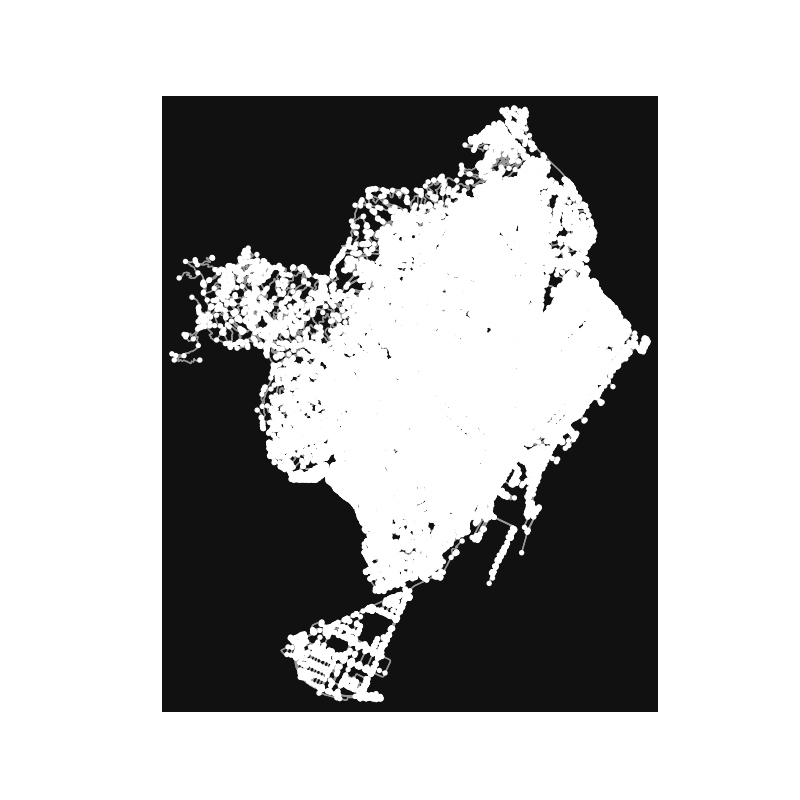

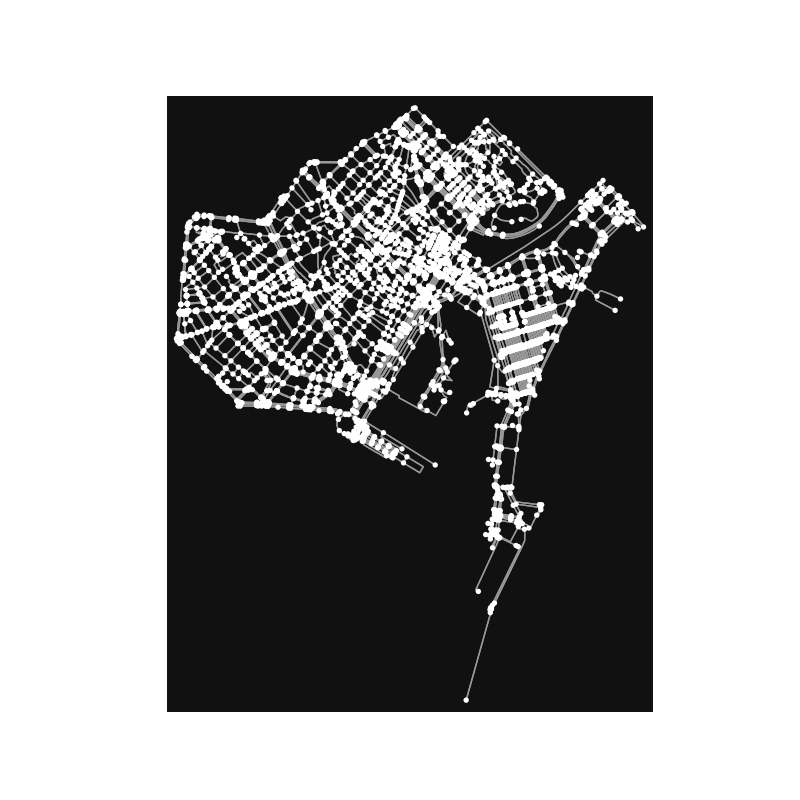

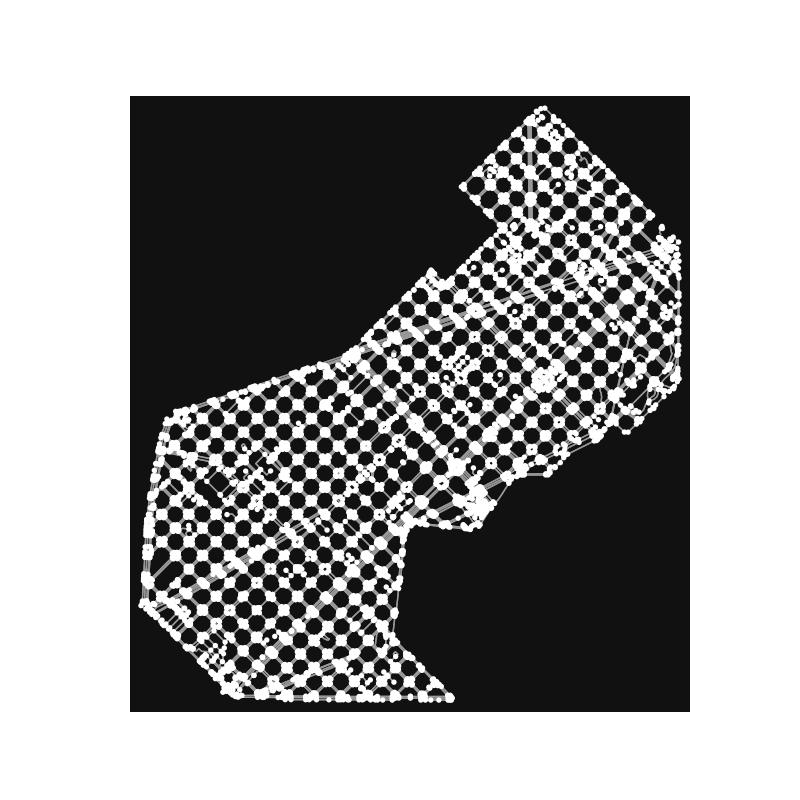

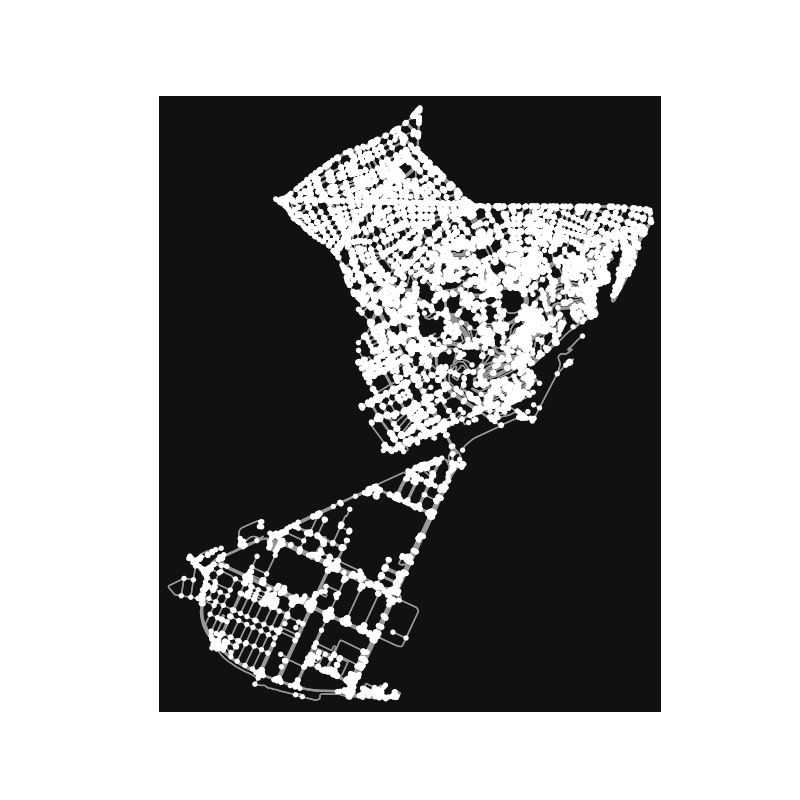

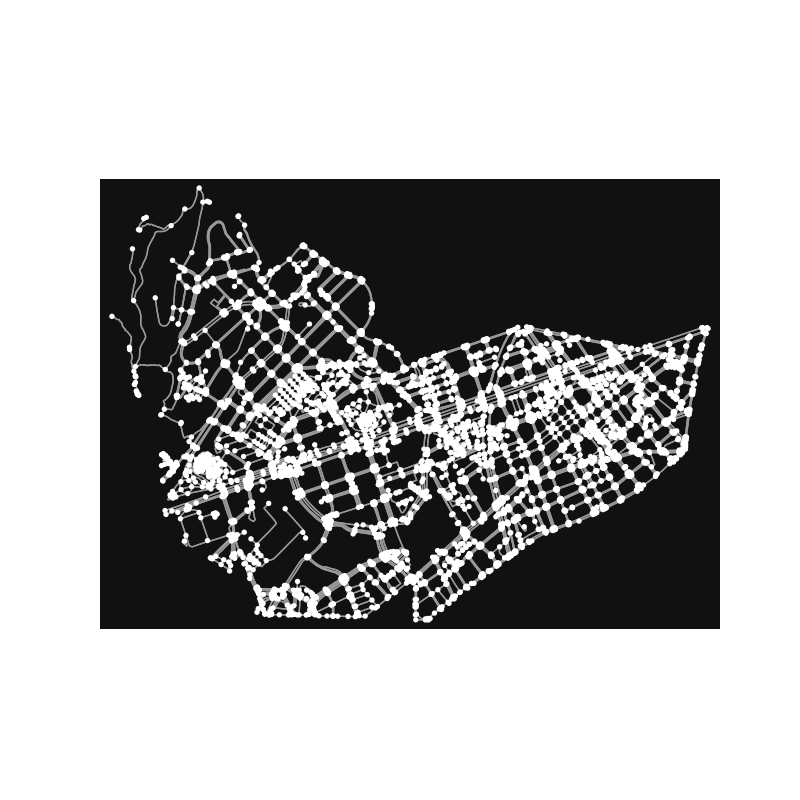

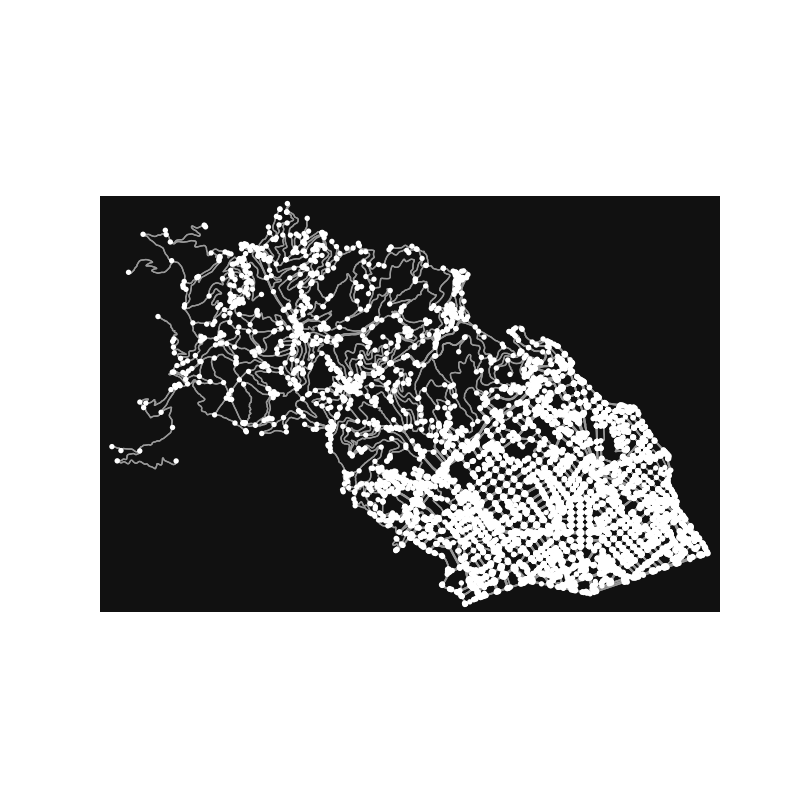

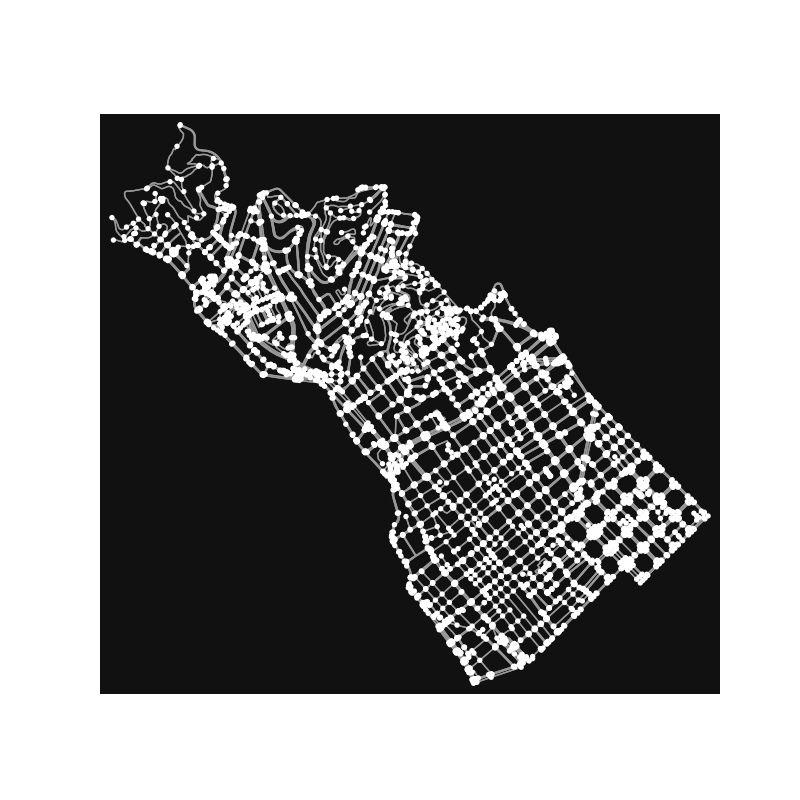

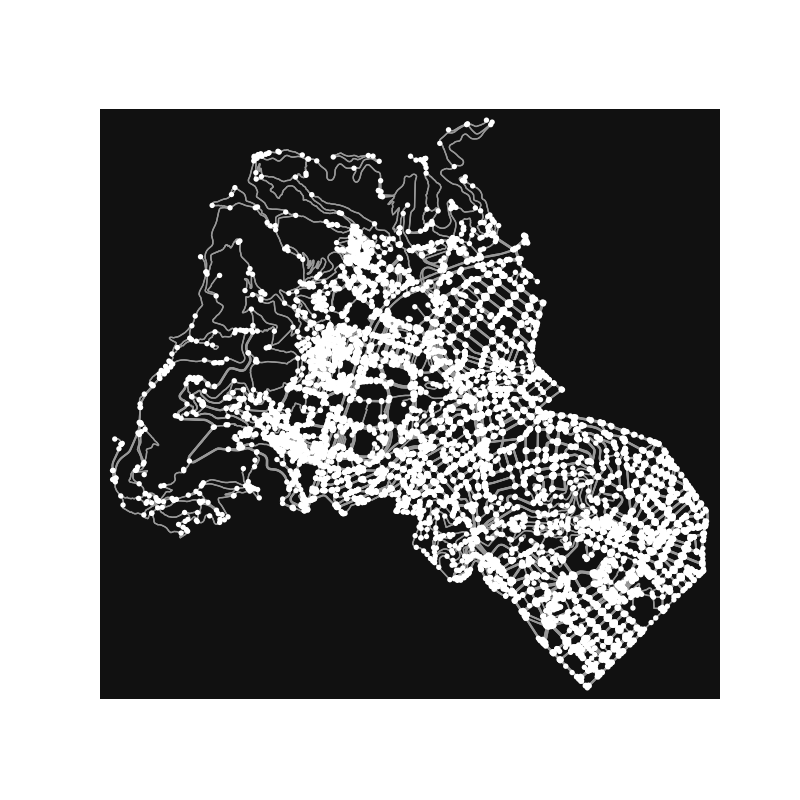

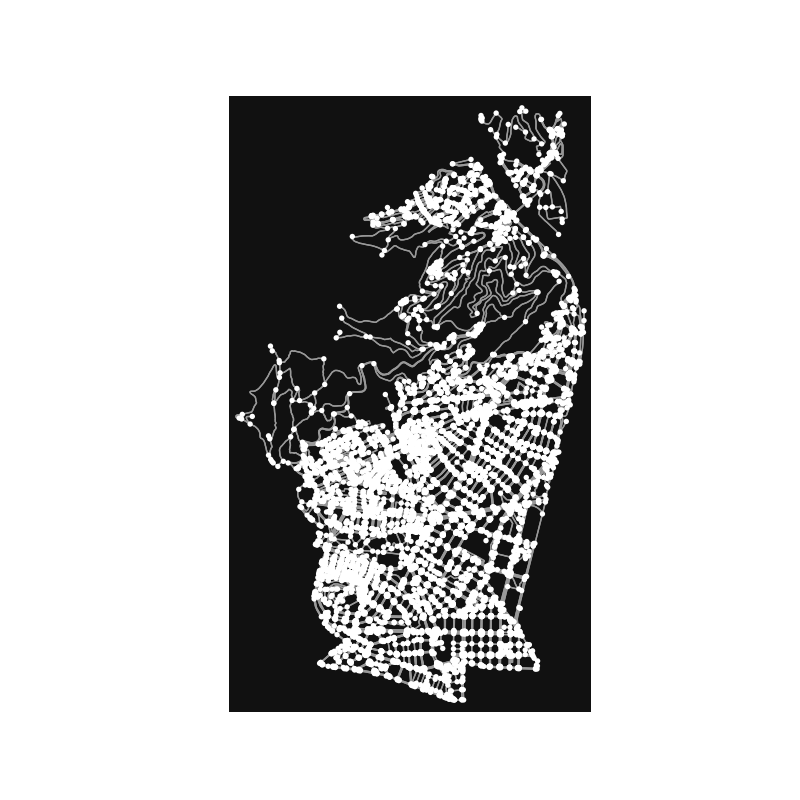

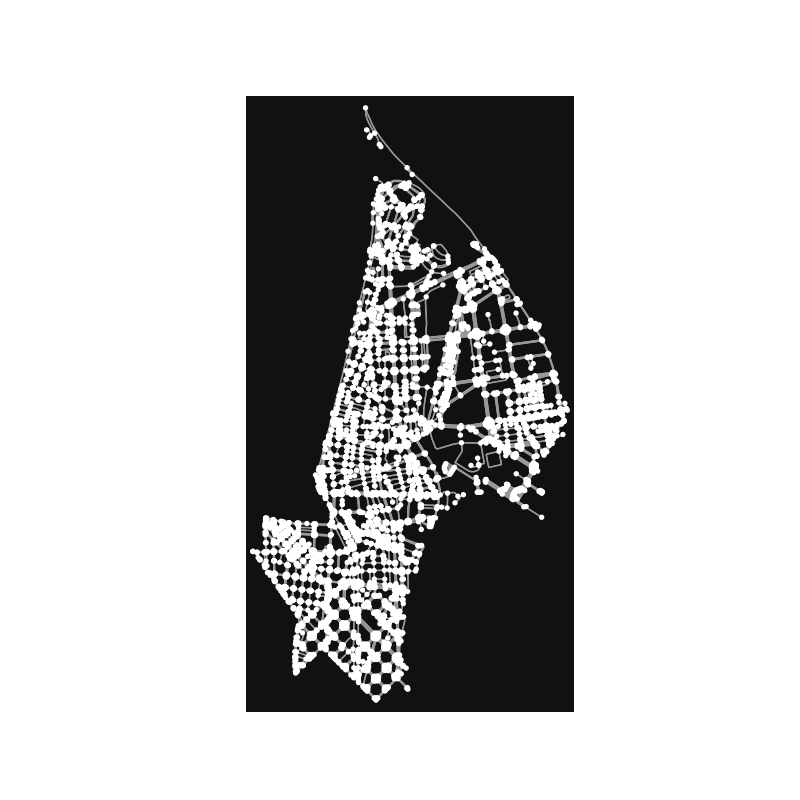

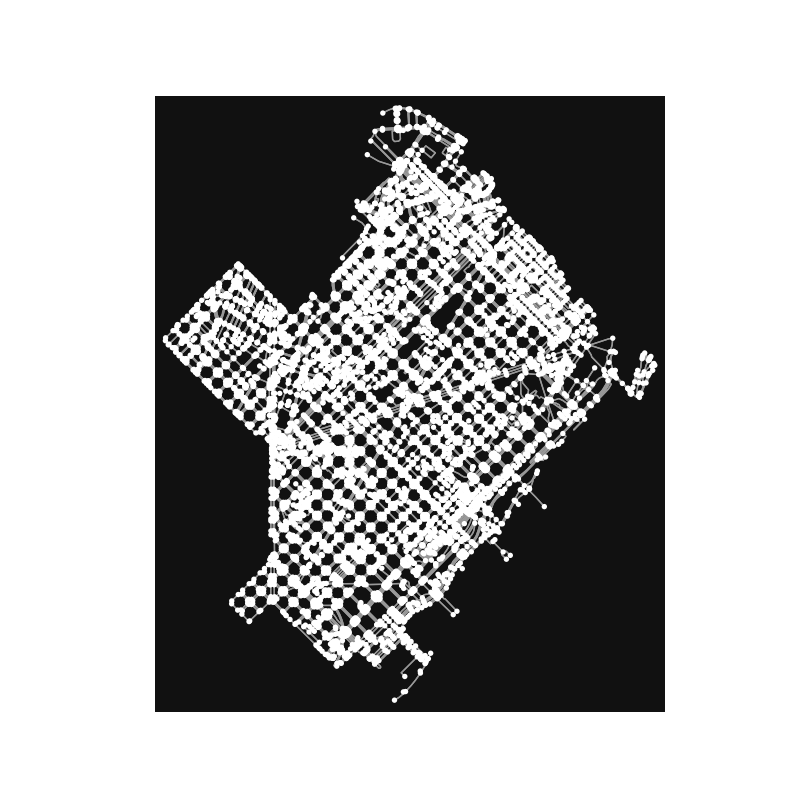

In [6]:
for district in list_districts:
    fig, ax = ox.plot.plot_graph(graph_dict[district])
    ax.set_title(district)

In [131]:
def get_graph_stats(graph):
    G_proj = ox.projection.project_graph(graph)
    nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
    graph_area_m = nodes_proj.union_all().convex_hull.area
    graph_area_m = nodes_proj.union_all().convex_hull.area
    stats = ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)
    return stats

In [132]:
get_graph_stats(graph_dict["Gracia"])

{'n': 4850,
 'm': 15592,
 'k_avg': 6.429690721649485,
 'edge_length_total': 498239.5385436048,
 'edge_length_avg': 31.95481904461293,
 'streets_per_node_avg': 3.2604123711340205,
 'streets_per_node_counts': {0: 0,
  1: 241,
  2: 0,
  3: 2882,
  4: 1711,
  5: 14,
  6: 2},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.049690721649484536,
  2: 0.0,
  3: 0.5942268041237113,
  4: 0.3527835051546392,
  5: 0.00288659793814433,
  6: 0.0004123711340206186},
 'intersection_count': 4609,
 'street_length_total': 249119.76927180236,
 'street_segment_count': 7796,
 'street_length_avg': 31.954819044612925,
 'circuity_avg': 1.0492651598911902,
 'self_loop_proportion': 0.0007696254489481786,
 'clean_intersection_count': 654,
 'node_density_km': 901.9272590959555,
 'intersection_density_km': 857.1098427161359,
 'edge_density_km': 92654.80853028188,
 'street_density_km': 46327.40426514093,
 'clean_intersection_density_km': 121.62070669046493}

In [134]:
stats = {}
for district in list_districts:
    stats[district]= get_graph_stats(graph_dict[district])
    print(district,stats[district])

Barcelona {'n': 72677, 'm': 231534, 'k_avg': 6.371589361145892, 'edge_length_total': 8040109.0954164, 'edge_length_avg': 34.7253927950815, 'streets_per_node_avg': 3.192069017708491, 'streets_per_node_counts': {0: 0, 1: 4889, 2: 1, 3: 44450, 4: 22983, 5: 314, 6: 35, 7: 3, 8: 2}, 'streets_per_node_proportions': {0: 0.0, 1: 0.06727025056070009, 2: 1.3759511262159968e-05, 3: 0.6116102756030106, 4: 0.31623484733822255, 5: 0.00432048653631823, 6: 0.0004815828941755989, 7: 4.12785337864799e-05, 8: 2.7519022524319936e-05}, 'intersection_count': 67788, 'street_length_total': 4020054.5477082, 'street_segment_count': 115767, 'street_length_avg': 34.7253927950815, 'circuity_avg': 1.0514610801855886, 'self_loop_proportion': 0.0007255953769208841, 'clean_intersection_count': 8784, 'node_density_km': 550.3128413636383, 'intersection_density_km': 513.2931586383356, 'edge_density_km': 60879.99341156392, 'street_density_km': 30439.99670578196, 'clean_intersection_density_km': 66.51276192658199}
Ciutat V

In [135]:
#example of access to stats of given district
total_street_length = stats["Barcelona"]["edge_length_total"]/1000.
print(total_street_length)
print(stats["Gracia"]["edge_length_total"]/1000.)


8040.109095416399
498.2395385436048


In [136]:
#Example of access to coords of node of 1 district
node_id = list(graph_dict[district].nodes)[2]
graph_dict[district].nodes[node_id]

{'y': 41.3896468, 'x': 2.1914943, 'street_count': 3}

In [138]:
nth_edge = 5
print("Attributes for the first",nth_edge,"edges")
for i, (u, v, k, data) in enumerate(graph_dict[district].edges(keys=True, data=True)):
    print(f"Edge ({u}, {v}, {k}):")
    print(data["name"])
    for key, value in data.items():
        print(f"  - {key}: {value}")
    
    if i >= nth_edge:
        break

Attributes for the first 5 edges
Edge (30242971, 12945382589, 0):
Carrer de Buenaventura Muñoz
  - osmid: 1408659413
  - highway: secondary
  - lanes: 2
  - maxspeed: 30
  - name: Carrer de Buenaventura Muñoz
  - oneway: False
  - reversed: False
  - length: 5.623923962672086
  - geometry: LINESTRING (2.1868056 41.3931146, 2.1868329 41.3931383, 2.1868512 41.3931518)
Edge (30242973, 7309041609, 0):
Carrer de Llull
  - osmid: 546148428
  - highway: living_street
  - maxspeed: 10
  - name: Carrer de Llull
  - oneway: False
  - reversed: False
  - length: 26.480877708331832
  - geometry: LINESTRING (2.189113 41.3914648, 2.1889425 41.3913214, 2.1889005 41.3912879)
Edge (30242975, 7254110645, 0):
Carrer de Ramon Trias Fargas
  - osmid: 22689284
  - highway: tertiary
  - lanes: 2
  - maxspeed: 50
  - name: Carrer de Ramon Trias Fargas
  - oneway: False
  - reversed: True
  - length: 24.86924672957129
Edge (30242975, 7309041636, 0):
Carrer del Doctor Trueta
  - osmid: 4751884
  - highway: resi

In [140]:
edge_number = 6
nth_edge = None
edge_iterator = iter(graph_dict[district].edges(keys=True))

for _ in range(edge_number + 1):
        nth_edge = next(edge_iterator)
    
print("edge ", edge_number,nth_edge)


edge  6 (30242976, 71709940, 0)


In [141]:
coords_casa = [41.400971,2.160001] #from gmaps
coords_casa_hub = [41.4152636,2.1648925]

In [142]:
#test if lat,lon falls back on right street name
# 
u, v, k = ox.nearest_edges(
    graph_dict["Gracia"], 
    X=coords_casa[1], 
    Y=coords_casa[0]
)
print(u,v,k)
edge_attributes = graph_dict["Gracia"].get_edge_data(u, v, k)
edge_attributes.get('name')

12309367556 8400777038 0


'Carrer de la Fraternitat'

In [143]:
def get_edge_from_coords(graph, coords):
    u, v, k = ox.nearest_edges(
    graph, 
    X=coords[1], 
    Y=coords[0]
    )
    edge_attributes = graph.get_edge_data(u, v, k)
    if type(edge_attributes.get('name')) == str:  
        street_name = edge_attributes.get('name') #usually a string
    else:
        try:
            street_name = edge_attributes.get('name')[0] #edge with coords (41.4049091 2.1738864), (41.4052928 2.1755545) has Provenca and Marina
        except:
            street_name = "Unkwown" # edge from point 867 or 868 from PA has no street name
    #print(type(street_name),street_name)
    length_edge = edge_attributes.get('length')

    return((u,v,k),street_name, length_edge)
    

In [166]:
def get_coords_gpx(user,n_segments=None):
    file = glob.glob(f'segments/{user}/*.gpx')[0] 
    gpx_file = open(file, 'r') 
    gpx = gpxpy.parse(gpx_file) 
    coords_gpx = []
    for track in gpx.tracks:
        for s, segment in enumerate(gpx.tracks[0].segments):
            if (user == 'hubert') & (s in [1, 6]):
                continue
            if n_segments and s >= n_segments:
                return coords_gpx
            for points in segment.points:
                coords_gpx.append((points.latitude,points.longitude))
    return coords_gpx
user = "pa"
coords_gpx = get_coords_gpx(user)
len(coords_gpx_pa)


13739

In [167]:
coords_gpx_pa

[(41.400205, 2.168775),
 (41.4003167, 2.16898),
 (41.400475, 2.1691583),
 (41.4006067, 2.1693533),
 (41.4007483, 2.169525),
 (41.400915, 2.16965),
 (41.401075, 2.1698217),
 (41.40122, 2.170015),
 (41.40138, 2.1702017),
 (41.401505, 2.1703767),
 (41.4016317, 2.1705917),
 (41.4017767, 2.1707667),
 (41.4019183, 2.1709367),
 (41.402035, 2.1711667),
 (41.4021933, 2.17132),
 (41.402355, 2.1714633),
 (41.4024817, 2.1716567),
 (41.4026133, 2.1718467),
 (41.4027683, 2.1720217),
 (41.4029233, 2.1722267),
 (41.4030717, 2.172405),
 (41.4032, 2.172615),
 (41.4033333, 2.1727967),
 (41.4034733, 2.17296),
 (41.4035633, 2.1731833),
 (41.4037083, 2.1733717),
 (41.4038433, 2.173535),
 (41.40398, 2.173735),
 (41.40411, 2.1739017),
 (41.404255, 2.1740533),
 (41.4043883, 2.174235),
 (41.4045133, 2.1744167),
 (41.404665, 2.1745833),
 (41.4047883, 2.174765),
 (41.404925, 2.1749517),
 (41.40508, 2.1751417),
 (41.4052067, 2.1753317),
 (41.40535, 2.17551),
 (41.4054683, 2.175695),
 (41.405605, 2.1758783),
 (41.4

In [171]:
def get_list_edges(graph):
  list_edges = []
  i=0
  for lat, lon in coords_gpx:
  #  if i < 100:
        if i%100 == 0:
            print(i,"/",len(coords_gpx))
        edge_and_name_and_length = get_edge_from_coords(graph,[lat,lon])
        if edge_and_name_and_length not in list_edges:
            if i%100 == 0:
                print("edge_and_name_and_length",edge_and_name_and_length)
            list_edges.append(edge_and_name_and_length)
        i=i+1
  #  else:
  #      break
  return list_edges

In [173]:
get_edge_from_coords(graph_dict["Gracia"],[47,1])
get_list_edges(graph_dict[district])

0 / 13739
edge_and_name_and_length ((126797329, 2874232227, 0), 'Carrer de Provença', 18.737313646852773)


KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__dealloc__'
Traceback (most recent call last):
  File "zmq/backend/cython/_zmq.py", line 179, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


In [1]:
def generate_list_edges(graph_dict):
    list_edges={}
    for district in list_districts:
        print(district)
        list_edges = get_list_edges(graph_dict[district],user)
    return list_edges

In [165]:
generate_list_edges(graph_dict[district],"pa")

Barcelona


TypeError: string indices must be integers, not 'str'

In [83]:
def highlight_edges(graph,list_edges):
    highlighted_edges_set = {
        data[0] 
        for data in list_edges
    }



    edge_colors = []
    for u, v, k in graph.edges(keys=True):
        edge_id = (u, v, k)
    
        if edge_id in highlighted_edges_set:
            edge_colors.append("r")
        else:
        # Assign black if the edge is NOT in your list
            edge_colors.append("k")
    return edge_colors

In [85]:
edge_colors={}
for district in list_districts:
    print(district)
    edge_colors[district]= highlight_edges(graph_dict_biking[district],list_edges[district])


Barcelona
Ciutat Vella
Eixample
Sants–Montjuic
Les Corts
Sarria-Sant Gervasi
Gracia
Horta-Guinardo
Nou Barris
Sant Andreu
Sant Marti


In [169]:
#type(list_edges)
#n=len(list_edges)
#list_edges[:][0]
#edge_colors

Barcelona
Ciutat Vella
Eixample
Sants–Montjuic
Les Corts
Sarria-Sant Gervasi
Gracia
Horta-Guinardo
Nou Barris
Sant Andreu
Sant Marti


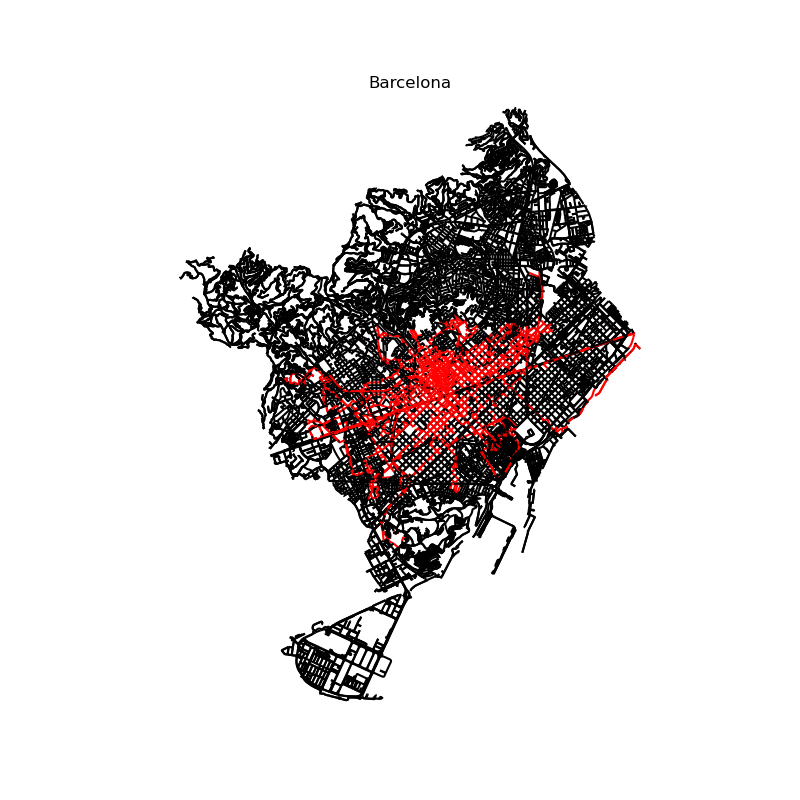

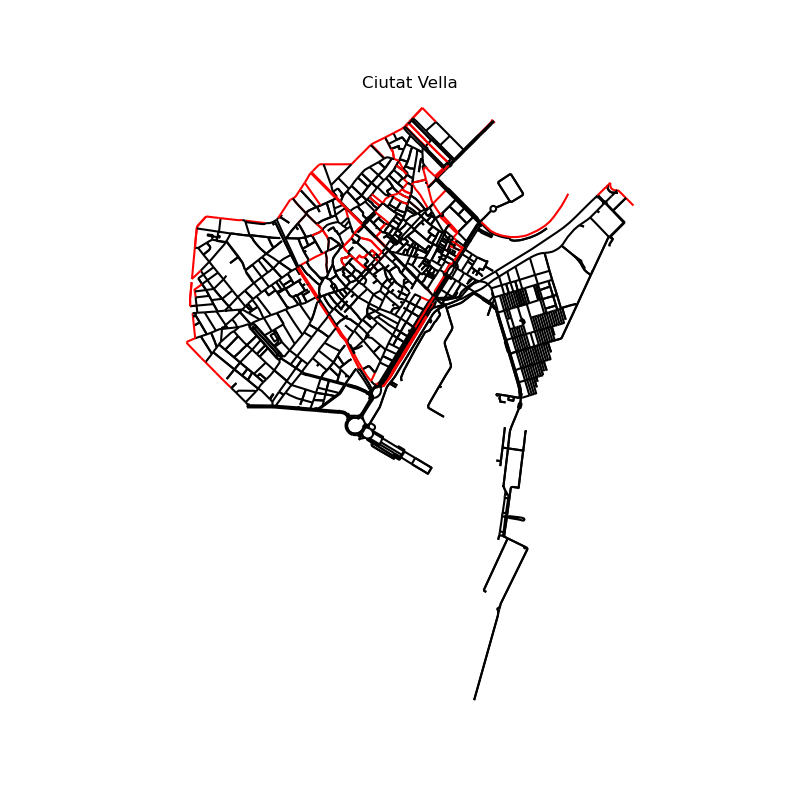

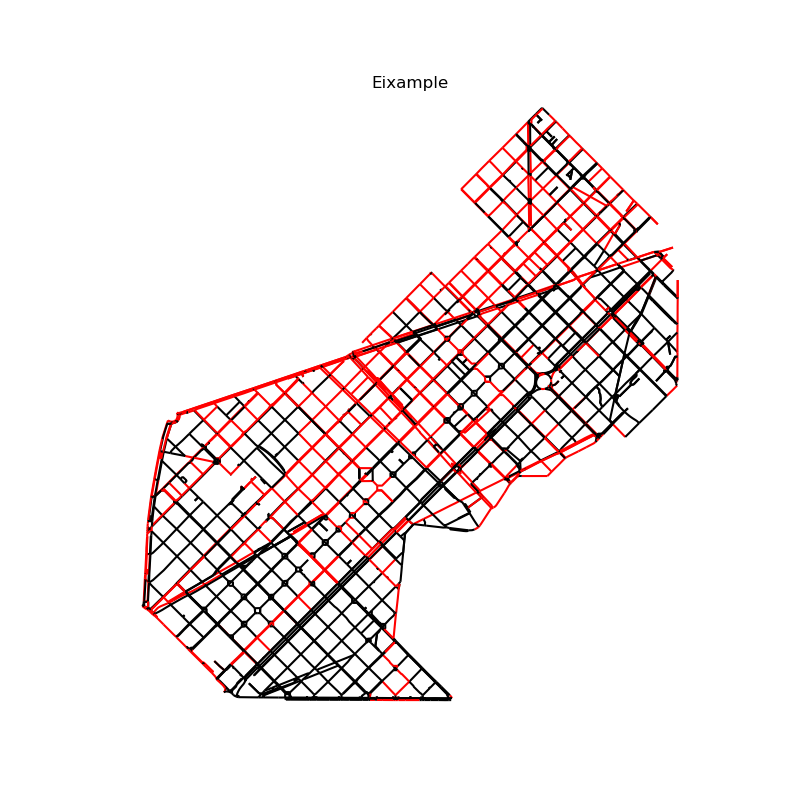

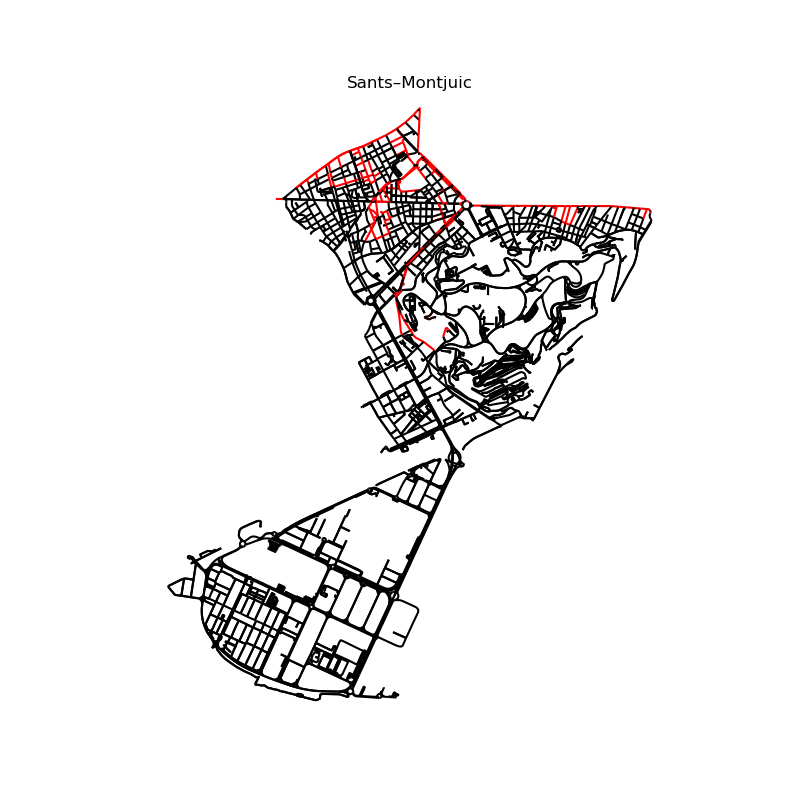

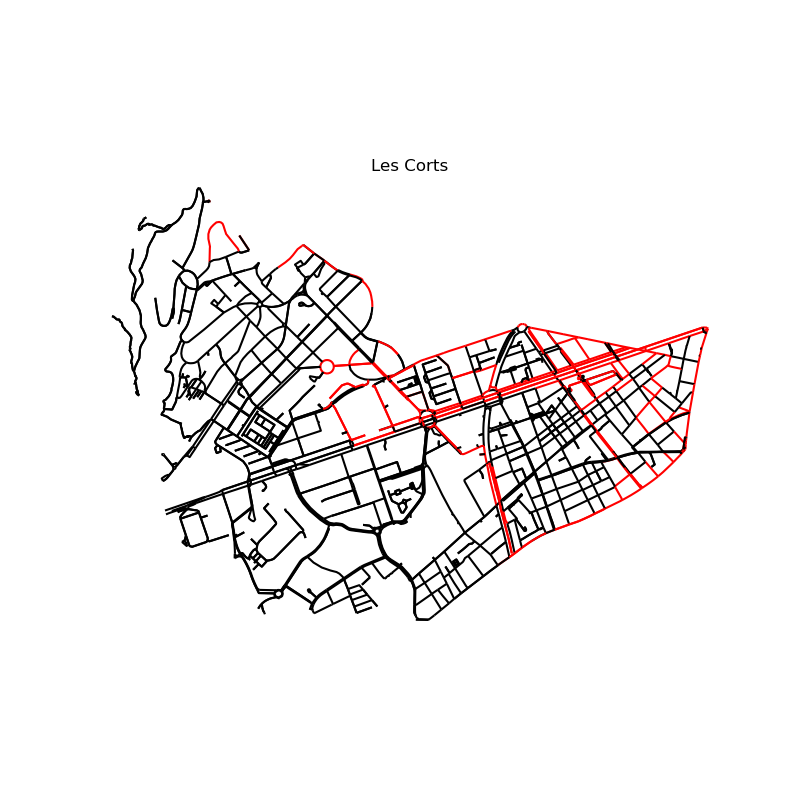

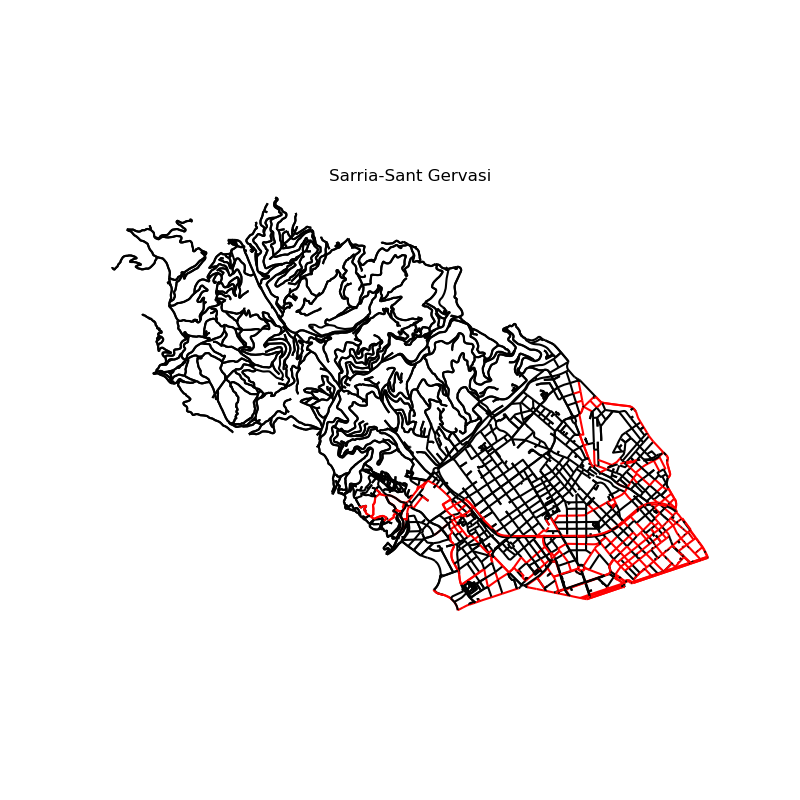

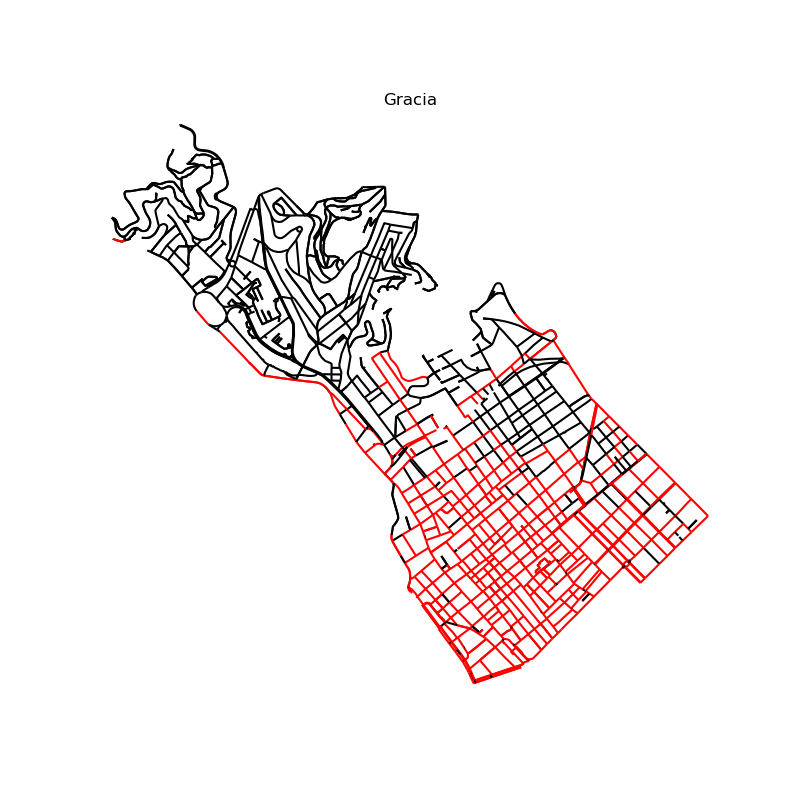

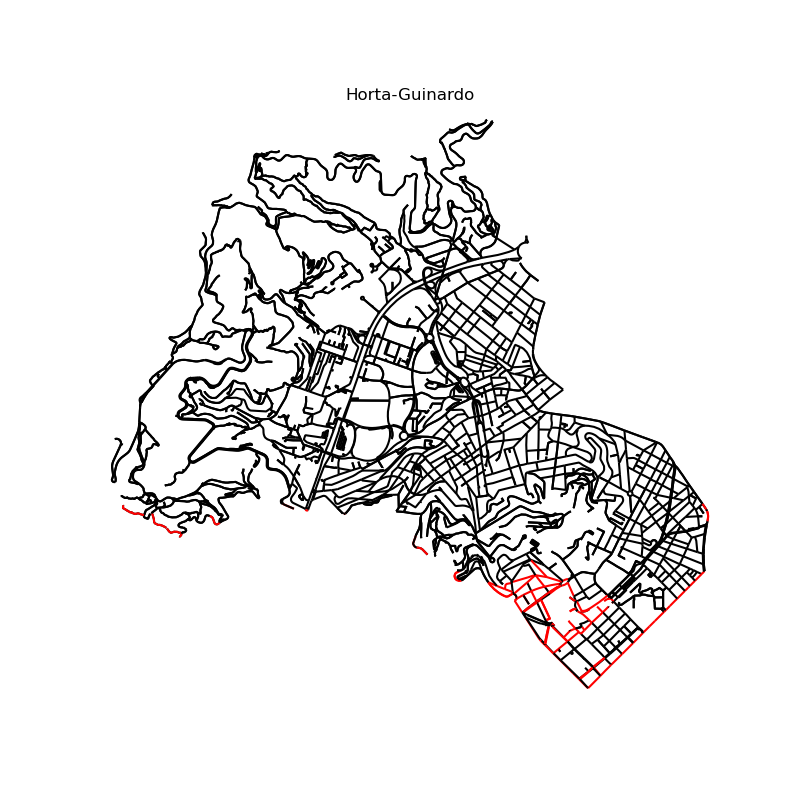

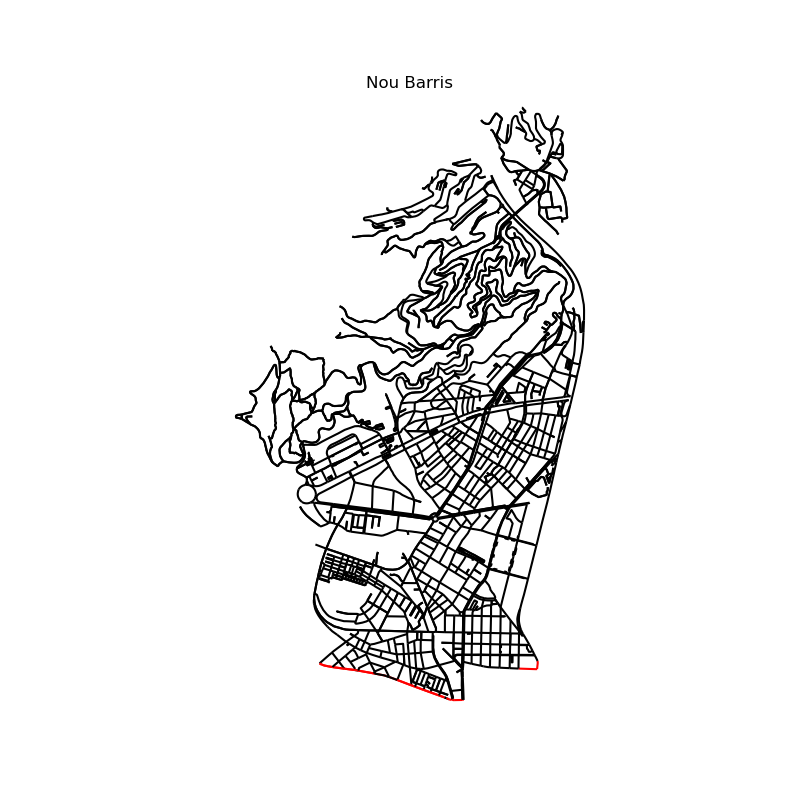

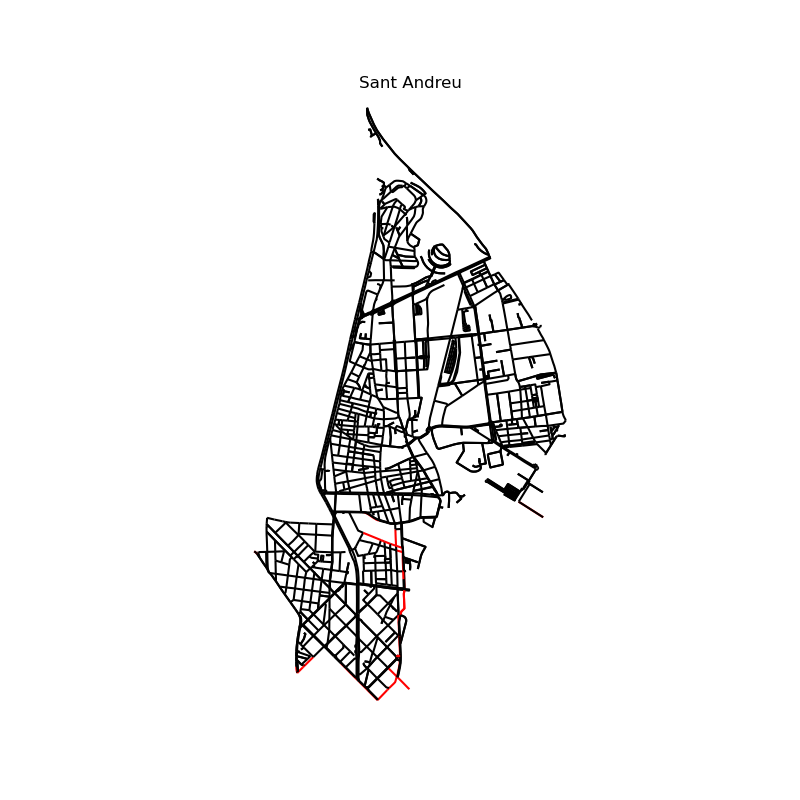

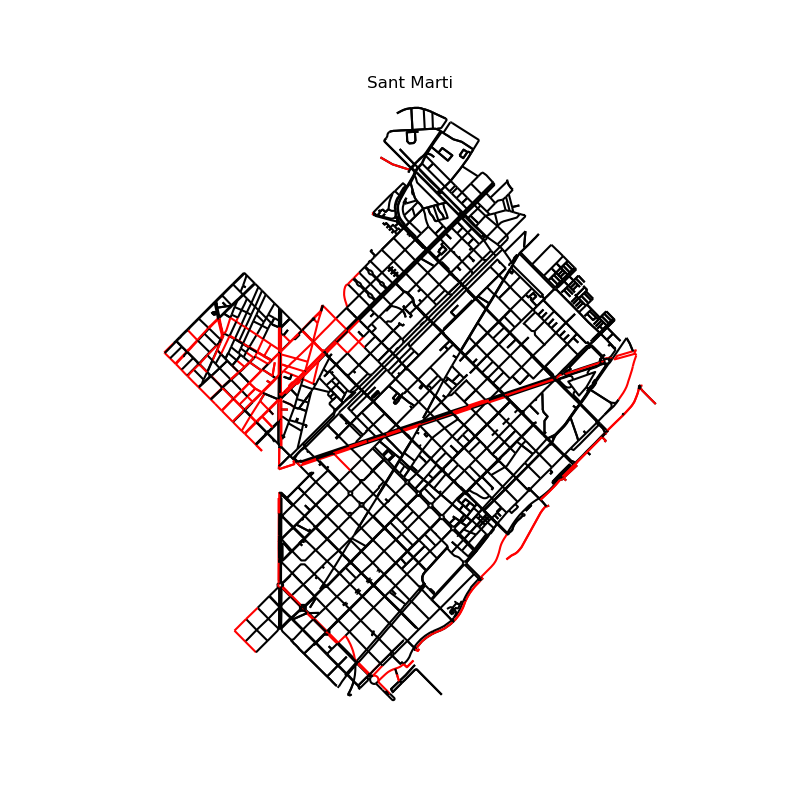

In [109]:
for district in list_districts:
    print(district)
    edge_colors[district]= highlight_edges(graph_dict_biking[district],list_edges[district])

    fig, ax = ox.plot.plot_graph(
        graph_dict_biking[district],
        edge_color=edge_colors[district],
        edge_linewidth=1.5,
        show=False,
        close=False,
        node_zorder=0,
        bgcolor="w"
    )
    ax.set_title(district)

In [88]:
def get_number_of_mapped_streets(list_edges):
    mapped_street_names = [edge_data[1] for edge_data in list_edges]
    return len(set(mapped_street_names))

In [112]:
def get_number_of_streets(graph):
    
    unique_street_names_from_G = set()

# Iterate over all edges in the graph, retrieving the attribute data for each edge
# We use keys=False because the u, v, k are not strictly needed for this task,
# only the data dictionary is.
    for _, _, data in graph.edges(data=True):
    # The street name is stored under the key 'name'
        name_entry = data.get('name')
    
    # Check if the 'name' attribute exists
        if name_entry is not None:
            
            if isinstance(name_entry, list):
                # If the value is a list (multiple names), add all individual names to the set
                for name in name_entry:
                    unique_street_names_from_G.add(name)
            elif isinstance(name_entry, str):
            # If the value is a single string, add it to the set
                unique_street_names_from_G.add(name_entry)

# The count of unique street names is the length of the final set
    count_unique_names_G = len(unique_street_names_from_G)
    #print("Total number of streets",count_unique_names_G)
    return count_unique_names_G


In [116]:
number_of_mapped_streets = []
total_number_of_streets = []
number_of_mapped_segments = []
total_number_of_segments = []
mapped_kms = []
total_street_length = []

for district in list_districts:
    number_of_mapped_streets.append(get_number_of_mapped_streets(list_edges[district]))
    total_number_of_streets.append(get_number_of_streets(graph_dict_biking[district]))
    number_of_mapped_segments.append(len(list_edges[district]))
    total_number_of_segments.append(stats[district]["m"])
    mapped_kms.append(sum(edge[2] for edge in list_edges[district])/1000)
    total_street_length.append(stats[district]["edge_length_total"]/1000)

df = pd.DataFrame({
    "number of mapped streets": number_of_mapped_streets,
    "total number of streets": total_number_of_streets,
    "percentage street": np.array(number_of_mapped_streets)/np.array(total_number_of_streets)*100,
    "number of mapped segments ": number_of_mapped_segments,
    "total number of segments" : total_number_of_segments, 
    "percentage segments": np.array(number_of_mapped_segments)/np.array(total_number_of_segments)*100,
    "mapped kms": mapped_kms,
    "total street length": total_street_length,
    "percentage km": np.array(mapped_kms)/np.array(total_street_length)*100
})
df.style \
  .format(precision=1) \
  .format_index(str.upper, axis=1) \
  .relabel_index(list_districts, axis=0)

,NUMBER OF MAPPED STREETS,TOTAL NUMBER OF STREETS,PERCENTAGE STREET,NUMBER OF MAPPED SEGMENTS,TOTAL NUMBER OF SEGMENTS,PERCENTAGE SEGMENTS,MAPPED KMS,TOTAL STREET LENGTH,PERCENTAGE KM
Barcelona,655,3693,17.7,3532,16493,21.4,300.5,1671.6,18.0
Ciutat Vella,87,566,15.4,224,864,25.9,18.6,72.6,25.6
Eixample,109,155,70.3,1145,1497,76.5,100.6,147.7,68.1
Sants–Montjuic,79,512,15.4,334,2404,13.9,25.3,253.7,10.0
Les Corts,60,241,24.9,322,1223,26.3,32.4,118.0,27.4
Sarria-Sant Gervasi,139,578,24.0,733,2467,29.7,55.3,284.4,19.4
Gracia,193,357,54.1,830,1324,62.7,56.8,110.6,51.4
Horta-Guinardo,39,476,8.2,131,2035,6.4,11.2,201.3,5.6
Nou Barris,5,356,1.4,36,1661,2.2,2.2,160.4,1.4
Sant Andreu,16,324,4.9,47,1493,3.1,3.8,139.4,2.7
